### Error Analysis + Explainability

Understand where the GRU model performs well or poorly and identify the features that influence RUL predictions.

#### Main Tasks

1. Analyze prediction errors
2. Study residuals
3. Compare errors across RUL ranges
4. Analyze worst predictions
5. Use SHAP for feature importance
6. Generate global and local explanations

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [66]:
PROJECT_ROOT = Path.cwd().parent

MODELS_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)

Project root: c:\Users\User\Desktop\jet-engine-predictive-maintenance
Models directory: c:\Users\User\Desktop\jet-engine-predictive-maintenance\models


In [67]:
results = pd.read_csv(
    MODELS_DIR / "gru_model_results.csv"
)

print(results.head())
print()
print("Results shape:", results.shape)

   actual_RUL  predicted_RUL  residual  absolute_error
0         125     124.897820  0.102180        0.102180
1         125     123.988884  1.011116        1.011116
2         125     121.558280  3.441719        3.441719
3         125     122.583590  2.416412        2.416412
4         125     118.395350  6.604652        6.604652

Results shape: (3690, 4)


In [68]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_dataset

train_df, test_df, rul_df = load_dataset("FD001")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


In [69]:
sequence_features = [
    f"sensor_{i}"
    for i in range(1, 22)
]

X_seq_data = train_df[sequence_features].copy()
y_seq_data = (
    train_df.groupby("unit")["cycle"]
    .transform("max")
    - train_df["cycle"]
)

X_seq_data = X_seq_data.fillna(0)

print("X sequence data:", X_seq_data.shape)
print("y sequence data:", y_seq_data.shape)

X sequence data: (20631, 21)
y sequence data: (20631,)


#### Residual Analysis

Residual:

**Residual = Actual RUL − Predicted RUL**

Positive residual → model underestimated RUL.

Negative residual → model overestimated RUL.

In [70]:
results["residual"] = (
    results["actual_RUL"]
    - results["predicted_RUL"]
)

results["absolute_error"] = (
    results["residual"].abs()
)

print(results.head())

   actual_RUL  predicted_RUL  residual  absolute_error
0         125     124.897820  0.102180        0.102180
1         125     123.988884  1.011116        1.011116
2         125     121.558280  3.441720        3.441720
3         125     122.583590  2.416410        2.416410
4         125     118.395350  6.604650        6.604650


In [71]:
mae = results["absolute_error"].mean()

rmse = np.sqrt(
    np.mean(results["residual"] ** 2)
)

print("GRU MAE:", mae)
print("GRU RMSE:", rmse)

GRU MAE: 9.638439791382657
GRU RMSE: 13.785263864278443


#### Residual Distribution

This shows how prediction errors are distributed around zero.

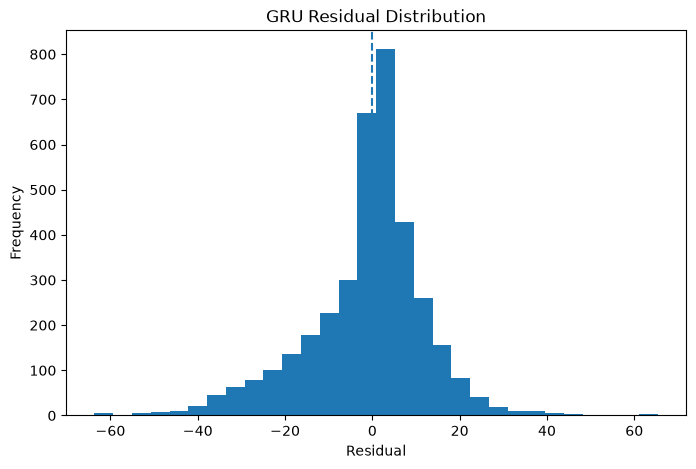

In [72]:
plt.figure(figsize=(8, 5))

plt.hist(
    results["residual"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("GRU Residual Distribution")

plt.show()

#### Actual vs Predicted RUL

A good model should produce predictions close to the diagonal relationship between actual and predicted RUL.

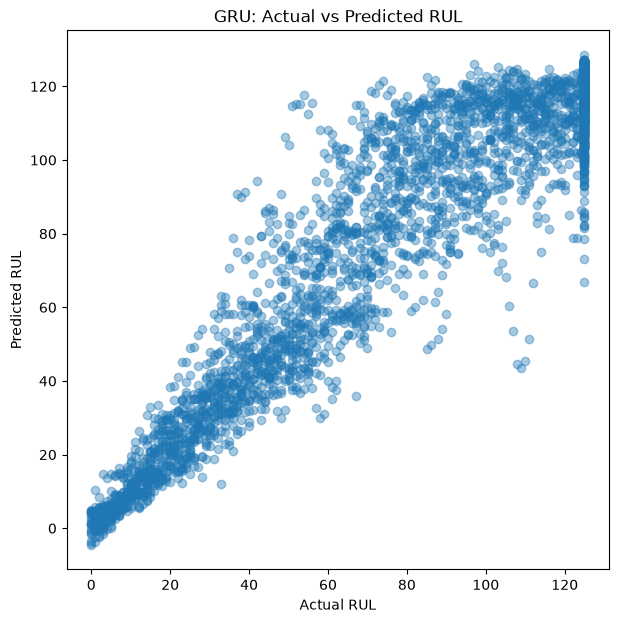

In [73]:
plt.figure(figsize=(7, 7))

plt.scatter(
    results["actual_RUL"],
    results["predicted_RUL"],
    alpha=0.4
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("GRU: Actual vs Predicted RUL")

plt.show()

#### Worst Prediction Errors

Identify the observations where the GRU made the largest errors.

In [74]:
worst_predictions = (
    results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

print(worst_predictions)

      actual_RUL  predicted_RUL   residual  absolute_error
3464         109      43.573353  65.426647       65.426647
3463         110      45.318913  64.681087       64.681087
118           54     117.679800 -63.679800       63.679800
121           51     114.574870 -63.574870       63.574870
3465         108      44.603558  63.396442       63.396442
120           52     115.187690 -63.187690       63.187690
119           53     115.300644 -62.300644       62.300644
3462         111      51.367466  59.632534       59.632534
116           56     115.581420 -59.581420       59.581420
1667         125      66.759790  58.240210       58.240210


#### Error by RUL Range

We investigate whether the model behaves differently for:

- Near-failure engines
- Mid-life engines
- Early-life engines

In [75]:
results["RUL_range"] = pd.cut(
    results["actual_RUL"],
    bins=[-1, 30, 70, np.inf],
    labels=[
        "Near Failure",
        "Mid Life",
        "Early Life"
    ]
)

range_error = (
    results
    .groupby("RUL_range", observed=False)["absolute_error"]
    .mean()
)

print(range_error)

RUL_range
Near Failure     4.368705
Mid Life        12.761129
Early Life       9.977244
Name: absolute_error, dtype: float64


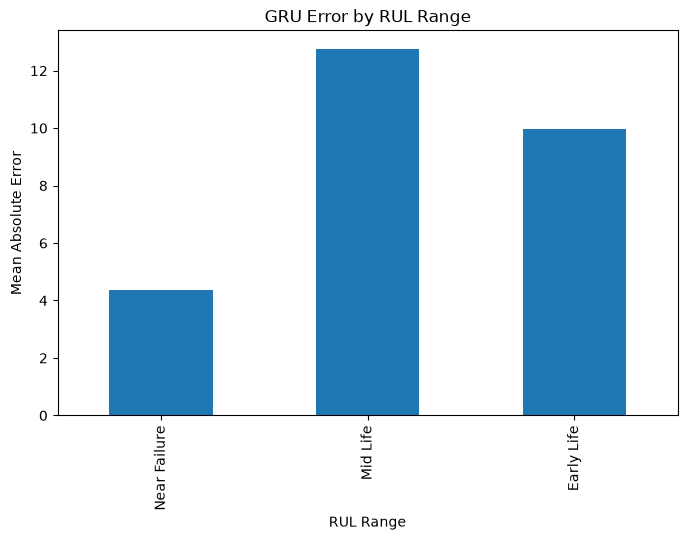

In [76]:
range_error.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("RUL Range")
plt.ylabel("Mean Absolute Error")
plt.title("GRU Error by RUL Range")

plt.show()

#### SHAP Explainability

SHAP is used to understand how features influence model predictions.

The goal is to identify the most influential sensor and temporal features.

#### Residual Summary

Residuals show the difference between actual and predicted RUL.

This helps identify whether the model systematically overpredicts or underpredicts RUL.

In [77]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [78]:
import pandas as pd

MODELS_DIR = PROJECT_ROOT / "models"

results = pd.read_csv(
    MODELS_DIR / "gru_model_results.csv"
)

print(results.head())
print("Results shape:", results.shape)

   actual_RUL  predicted_RUL  residual  absolute_error
0         125     124.897820  0.102180        0.102180
1         125     123.988884  1.011116        1.011116
2         125     121.558280  3.441719        3.441719
3         125     122.583590  2.416412        2.416412
4         125     118.395350  6.604652        6.604652
Results shape: (3690, 4)


In [79]:
print("Mean residual:", results["residual"].mean())
print("Median residual:", results["residual"].median())
print("Maximum absolute error:", results["absolute_error"].max())

Mean residual: -1.153064147897852
Median residual: 0.8476791381835938
Maximum absolute error: 65.4266471862793


#### Prediction Bias

We compare underpredictions and overpredictions.

- Positive residual → RUL was underestimated.
- Negative residual → RUL was overestimated.

In [80]:
underpredictions = (
    results["residual"] > 0
).sum()

overpredictions = (
    results["residual"] < 0
).sum()

print("Underpredictions:", underpredictions)
print("Overpredictions:", overpredictions)

Underpredictions: 2009
Overpredictions: 1681


In [81]:
if "range_error" not in globals():
    results["RUL_range"] = pd.cut(
        results["actual_RUL"],
        bins=[-1, 30, 70, np.inf],
        labels=["Near Failure", "Mid Life", "Early Life"]
    )

    range_error = (
        results
        .groupby("RUL_range", observed=False)["absolute_error"]
        .mean()
    )

range_error.to_csv(
    MODELS_DIR / "gru_error_by_rul_range.csv",
    index=True
)

print("RUL range error analysis saved.")

RUL range error analysis saved.


#### Worst Predictions

The largest prediction errors are saved for further investigation.

In [82]:
if "worst_predictions" not in globals():
    worst_predictions = (
        results
        .sort_values("absolute_error", ascending=False)
        .head(10)
        .copy()
    )

worst_predictions.to_csv(
    MODELS_DIR / "gru_worst_predictions.csv",
    index=False
)

print("Worst predictions saved.")



Worst predictions saved.


In [97]:
X_shap = X_lstm_val[:100].astype(np.float32)

print("X_shap:", X_shap.shape)

X_shap: (100, 20, 21)


#### GRU Feature Explanation

SHAP estimates how input features contribute to the model prediction.

Because the GRU processes sequences, the explanation contains both:

- time-step information
- sensor information

In [98]:
import shap

background = X_shap[:20]

explainer = shap.GradientExplainer(
    gru_model,
    background
)

print("SHAP explainer created.")

SHAP explainer created.


In [99]:
shap_values = explainer.shap_values(
    X_shap[:20]
)

print("SHAP values calculated.")

c:\Users\User\Desktop\jet-engine-predictive-maintenance\.venv-dl\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(20, 20, 21))']
  warnings.warn(msg)
c:\Users\User\Desktop\jet-engine-predictive-maintenance\.venv-dl\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(50, 20, 21))']
  warnings.warn(msg)


SHAP values calculated.


In [100]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [101]:
if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    print("First SHAP shape:", np.asarray(shap_values[0]).shape)
else:
    print("SHAP shape:", np.asarray(shap_values).shape)

SHAP shape: (20, 20, 21, 1)


In [102]:
shap_array = (
    shap_values[0]
    if isinstance(shap_values, list)
    else shap_values
)

shap_array = np.asarray(shap_array)

print("SHAP array shape:", shap_array.shape)

SHAP array shape: (20, 20, 21, 1)


In [103]:
if shap_array.ndim == 4:
    shap_array = shap_array[..., 0]

print("Adjusted SHAP shape:", shap_array.shape)

Adjusted SHAP shape: (20, 20, 21)


In [104]:
sensor_importance = np.mean(
    np.abs(shap_array),
    axis=(0, 1)
)

shap_importance = pd.DataFrame({
    "feature": sequence_features,
    "mean_abs_shap": sensor_importance
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print(shap_importance)

      feature  mean_abs_shap
11  sensor_12       0.119426
7    sensor_8       0.107009
10  sensor_11       0.091975
12  sensor_13       0.091692
6    sensor_7       0.072472
1    sensor_2       0.063720
2    sensor_3       0.059768
19  sensor_20       0.054517
3    sensor_4       0.052020
14  sensor_15       0.051394
20  sensor_21       0.046003
16  sensor_17       0.036749
13  sensor_14       0.030269
8    sensor_9       0.021650
0    sensor_1       0.000000
4    sensor_5       0.000000
5    sensor_6       0.000000
9   sensor_10       0.000000
15  sensor_16       0.000000
18  sensor_19       0.000000
17  sensor_18       0.000000


#### Global Feature Importance

The following plot shows which sensor features have the greatest average influence on GRU predictions.

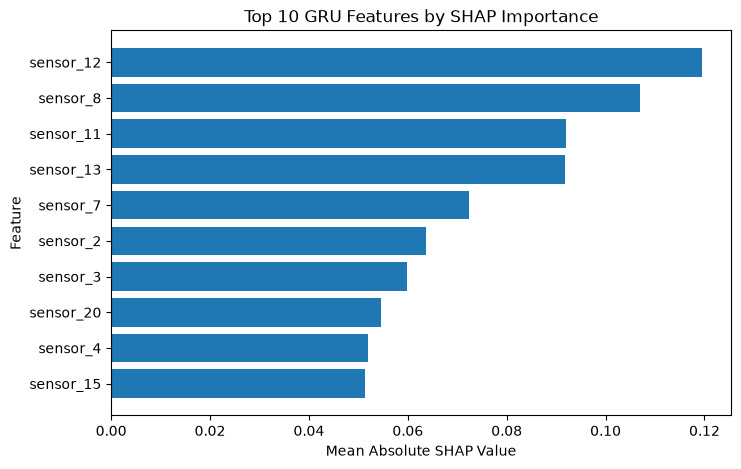

In [106]:
top_features = shap_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"][::-1],
    top_features["mean_abs_shap"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 GRU Features by SHAP Importance")

plt.show()

In [107]:
shap_importance.to_csv(
    MODELS_DIR / "gru_shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved.")

SHAP feature importance saved.


In [108]:
# Select one validation sequence
sample_index = 0

X_local = X_lstm_val[sample_index:sample_index + 1]
actual_local = y_lstm_val[sample_index]

predicted_local = gru_model.predict(
    X_local,
    verbose=0
).flatten()[0]

print("Actual RUL:", actual_local)
print("Predicted RUL:", predicted_local)
print("Absolute error:", abs(actual_local - predicted_local))

Actual RUL: 125
Predicted RUL: 124.89782
Absolute error: 0.10218048095703125


In [109]:
local_shap_values = explainer.shap_values(
    X_local
)

if isinstance(local_shap_values, list):
    local_sv = np.asarray(local_shap_values[0])
else:
    local_sv = np.asarray(local_shap_values)

print("Raw local SHAP shape:", local_sv.shape)

Raw local SHAP shape: (1, 20, 21, 1)


c:\Users\User\Desktop\jet-engine-predictive-maintenance\.venv-dl\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(1, 20, 21))']
  warnings.warn(msg)


In [110]:
# Remove output dimension if present
if local_sv.ndim == 4 and local_sv.shape[-1] == 1:
    local_sv = local_sv[..., 0]

# Aggregate across the 20 time steps
local_sensor_shap = local_sv.mean(axis=1).flatten()

print("Local sensor SHAP shape:", local_sensor_shap.shape)

Local sensor SHAP shape: (21,)


In [111]:
sensor_cols = [
    f"sensor_{i}"
    for i in range(1, 22)
]

local_explanation = pd.DataFrame({
    "feature": sensor_cols,
    "shap_value": local_sensor_shap
})

local_explanation["absolute_shap"] = (
    local_explanation["shap_value"].abs()
)

local_explanation = local_explanation.sort_values(
    "absolute_shap",
    ascending=False
).reset_index(drop=True)

print(local_explanation.head(10))

     feature  shap_value  absolute_shap
0  sensor_11    0.073031       0.073031
1   sensor_2   -0.036149       0.036149
2  sensor_13    0.028116       0.028116
3  sensor_12   -0.024596       0.024596
4   sensor_7    0.018670       0.018670
5   sensor_3    0.018388       0.018388
6  sensor_15   -0.018248       0.018248
7  sensor_20   -0.014280       0.014280
8  sensor_14   -0.011114       0.011114
9   sensor_4   -0.007805       0.007805


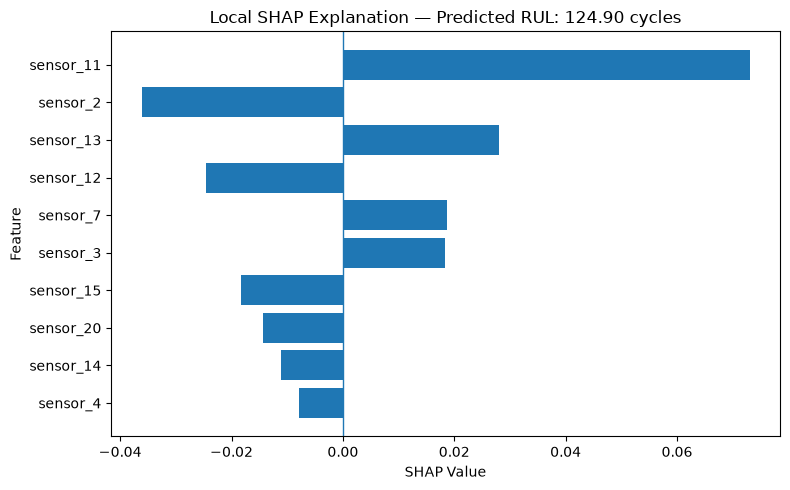

In [112]:
top_local = local_explanation.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_local["feature"][::-1],
    top_local["shap_value"][::-1]
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title(
    f"Local SHAP Explanation — Predicted RUL: "
    f"{predicted_local:.2f} cycles"
)

plt.tight_layout()
plt.show()

### Local Interpretation

For this particular prediction:

- sensor_11 had the strongest positive contribution.
- sensor_2 had the strongest negative contribution.
- sensor_13 also pushed the prediction upward.
- sensor_12 pushed the prediction downward.
- Other sensors provided smaller positive or negative contributions.

In [113]:
local_explanation.to_csv(
    MODELS_DIR / "gru_local_shap_explanation.csv",
    index=False
)

print("Local SHAP explanation saved.")

Local SHAP explanation saved.


#### Global explanation

The GRU relies most strongly on:

sensor_12
sensor_8
sensor_11

sensor_13
sensor_7

when making predictions across the analyzed validation samples.

### Local explanation

For an individual prediction, the most influential sensors can be different. In the selected example, sensor_11 was the strongest positive contributor, while sensor_2 was the strongest negative contributor.

This demonstrates that the GRU is not simply producing a prediction without explanation. Its predictions can be investigated in terms of the sensor measurements that contributed to them.

In [114]:
shap_importance.to_csv(
    MODELS_DIR / "gru_shap_feature_importance.csv",
    index=False
)

print("Global SHAP feature importance saved.")

Global SHAP feature importance saved.


### Summary

Notebook investigated both prediction errors and model explainability.

The analysis showed:

Residuals were calculated for the GRU validation predictions.
Absolute prediction errors were analyzed.
Performance was compared across early-life, mid-life, and near-failure RUL ranges.
The GRU achieved its lowest mean absolute error in the near-failure range.
SHAP was used for global feature importance.
sensor_12 was the most influential feature globally.
Local SHAP was used to explain an individual prediction.
The selected example predicted RUL with only 0.10 cycles of error.

Overall, notebook demonstrates that the GRU model can be evaluated not only by its predictive performance but also through error patterns and interpretable sensor-level explanations.

